# House Price Prediction

## Project Overview

This project predicts residential property prices from house size, layout, condition, renovation history, and location data. It combines exploratory data analysis with supervised machine-learning models to identify the strongest predictors of sale price and estimate prices for new properties.

## Objective

Build and evaluate regression models that produce accurate house-price estimates while using a consistent preprocessing workflow. The notebook cleans invalid records, engineers useful features such as house age, encodes location data, compares several models, and saves the trained Gradient Boosting model and preprocessing files for use in a Streamlit app.

**Dataset:** `modified_data.csv`  \n
**Target:** `price`  \n
**Main evaluation metrics:** R-squared, MAE, and RMSE


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('modified_data.csv')

In [3]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,233.58
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,653.15
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,177.20
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,210.00
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,283.51


In [4]:
df.shape

(4600, 18)

## Statistical Summary

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            4600 non-null   str    
 1   price           4600 non-null   float64
 2   bedrooms        4600 non-null   float64
 3   bathrooms       4600 non-null   float64
 4   sqft_living     4600 non-null   int64  
 5   sqft_lot        4600 non-null   int64  
 6   floors          4600 non-null   float64
 7   waterfront      4600 non-null   int64  
 8   view            4600 non-null   int64  
 9   condition       4600 non-null   int64  
 10  sqft_above      4600 non-null   int64  
 11  sqft_basement   4600 non-null   int64  
 12  yr_built        4600 non-null   int64  
 13  yr_renovated    4600 non-null   int64  
 14  street          4600 non-null   str    
 15  city            4600 non-null   str    
 16  statezip        4600 non-null   str    
 17  price_per_sqft  4600 non-null   float64
dtyp

In [6]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price_per_sqft
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261,265.876209
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536,357.503362
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000,180.817500
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000,243.855000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000,314.840000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000,22533.900000


In [7]:
df.isnull().sum()

date              0
price             0
bedrooms          0
bathrooms         0
sqft_living       0
sqft_lot          0
floors            0
waterfront        0
view              0
condition         0
sqft_above        0
sqft_basement     0
yr_built          0
yr_renovated      0
street            0
city              0
statezip          0
price_per_sqft    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'price_per_sqft'],
      dtype='str')

## Core Data Insights

- **Price distribution & skewness:** mean price is notably higher than the median, indicating a right-skewed
  distribution driven by high-end luxury properties.
- **Zero-value / data-quality issues:** `price`, `bedrooms`, and `bathrooms` all contain `0` values that need
  cleaning before modeling — these are handled explicitly below.
- **Property size:** `sqft_living` ranges from a few hundred to over 13,000 sqft.
- **Basements & renovations:** the majority of homes have no basement and no recorded renovation.


## EDA

First, convert `date` to a proper datetime type.

In [10]:
df['date'] = pd.to_datetime(df['date'])

In [11]:
# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

### Univariate Analysis

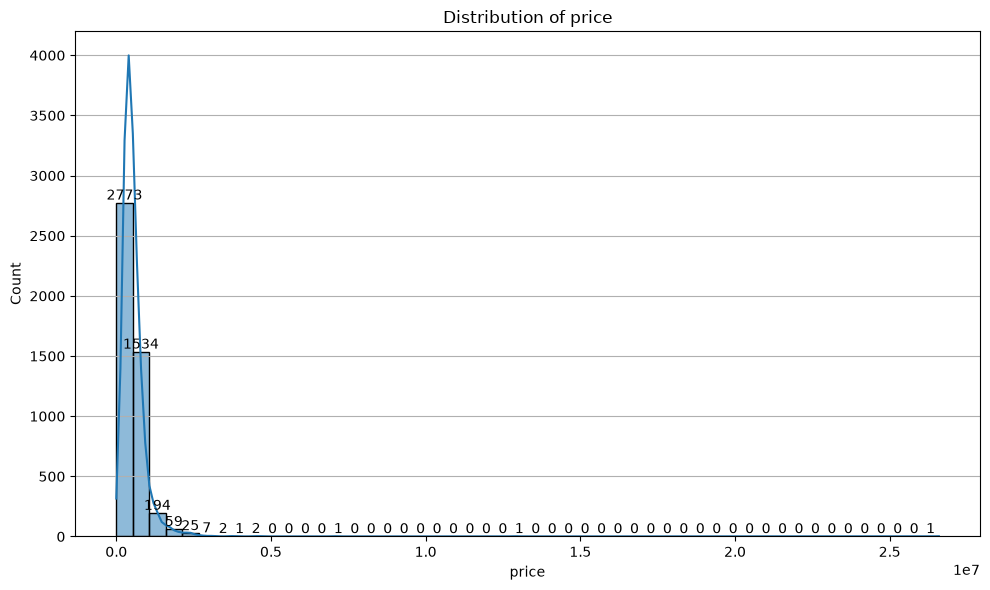

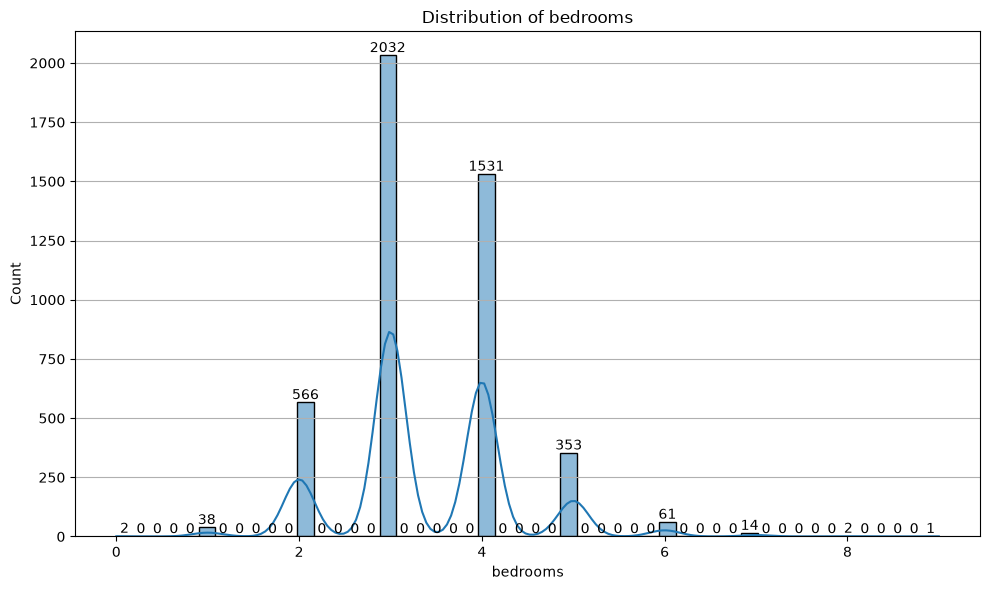

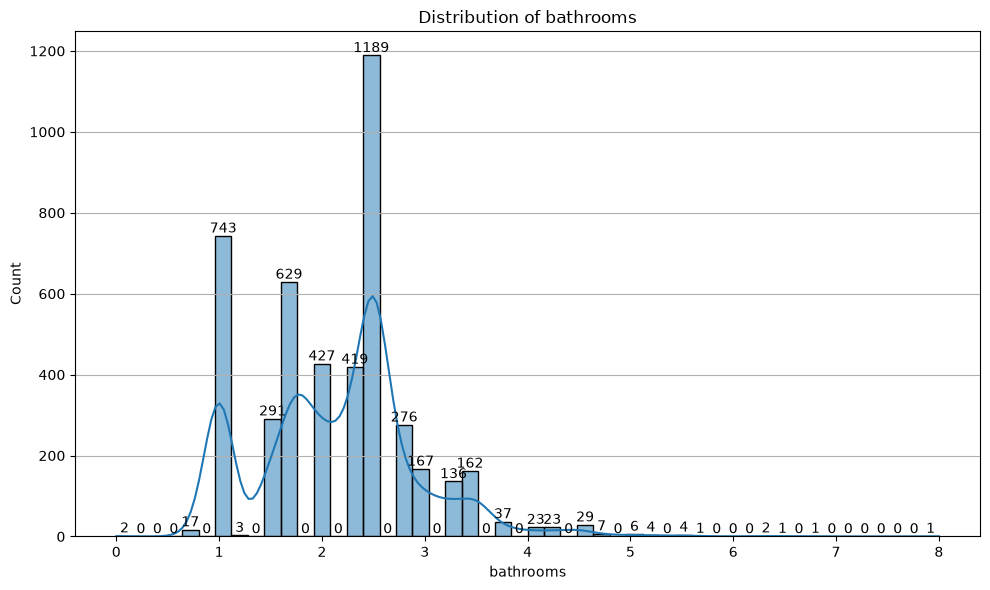

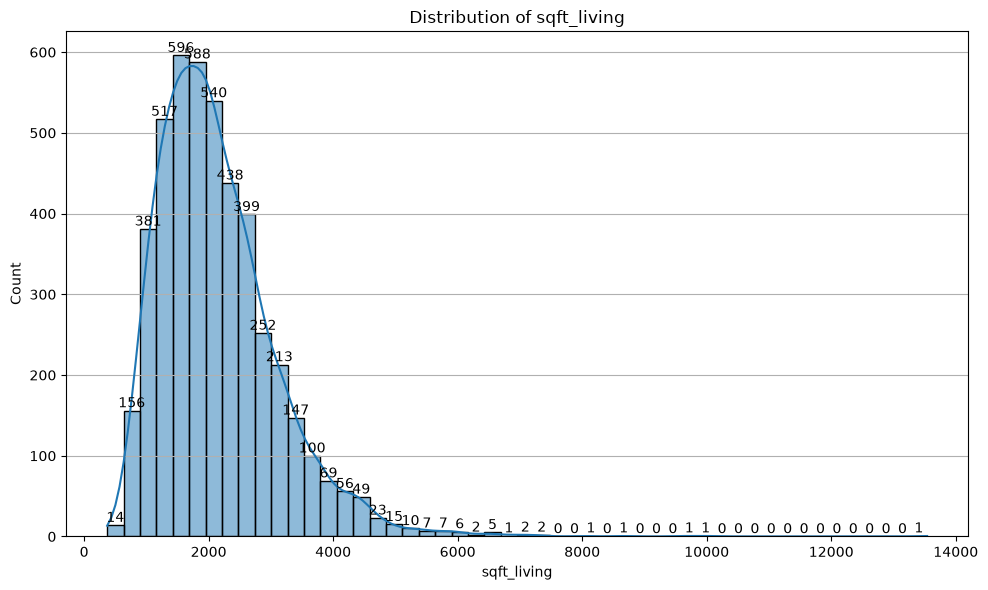

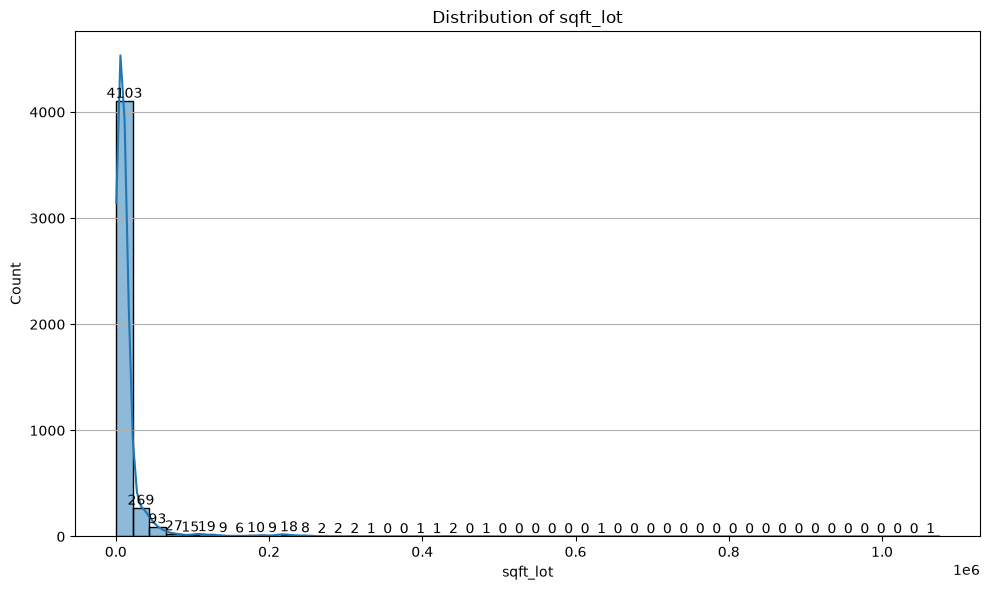

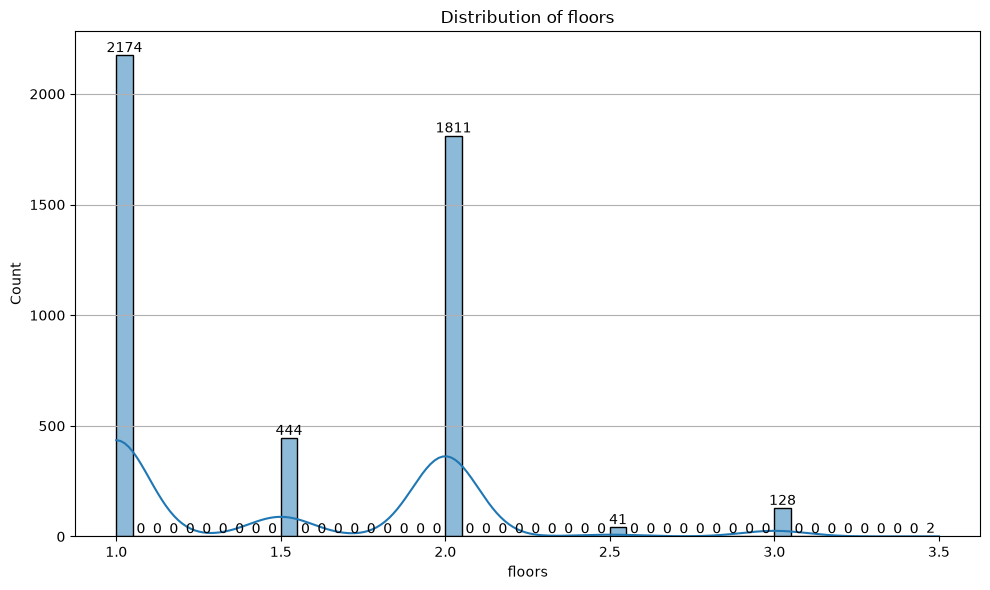

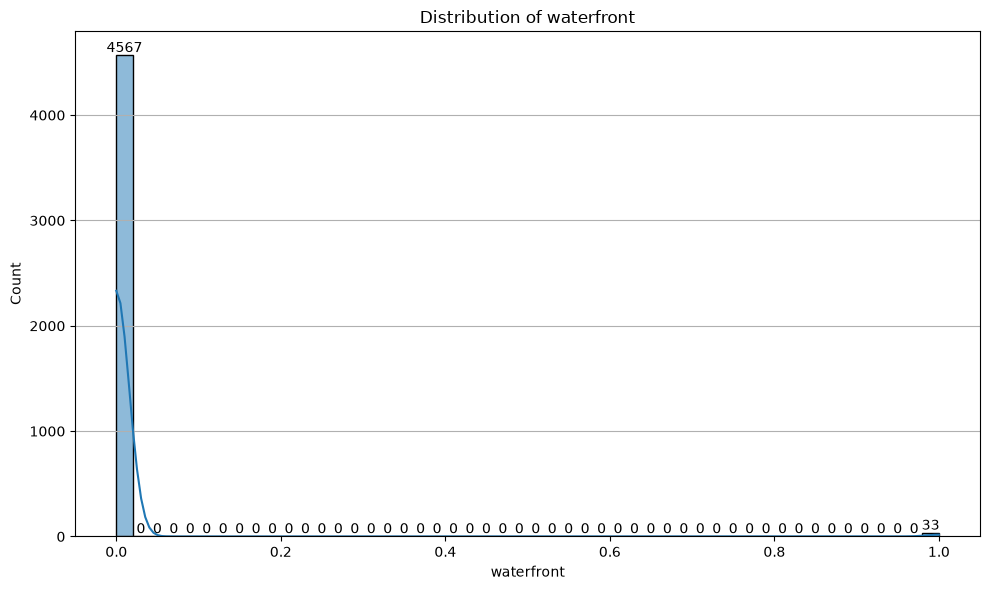

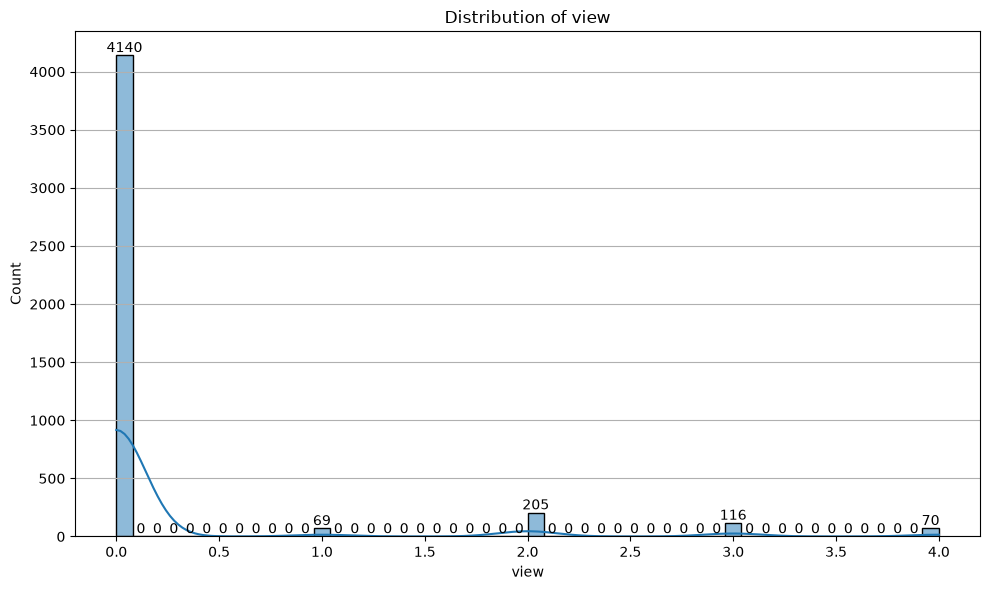

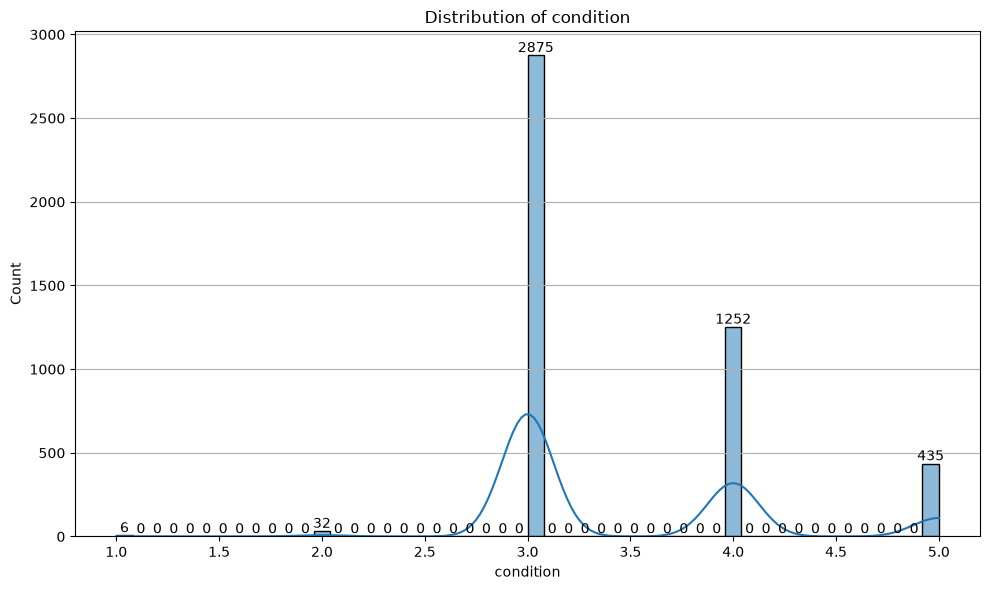

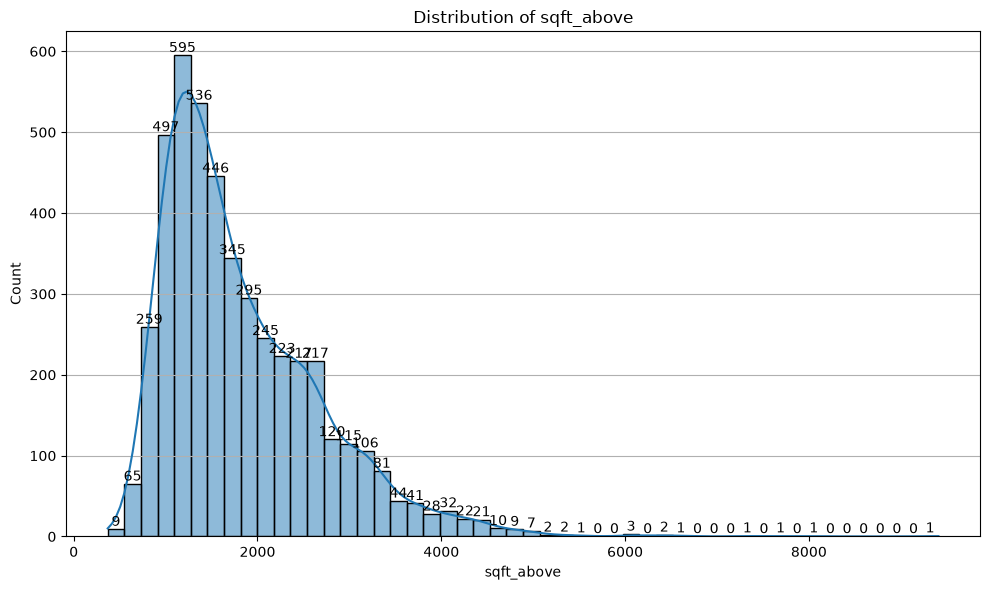

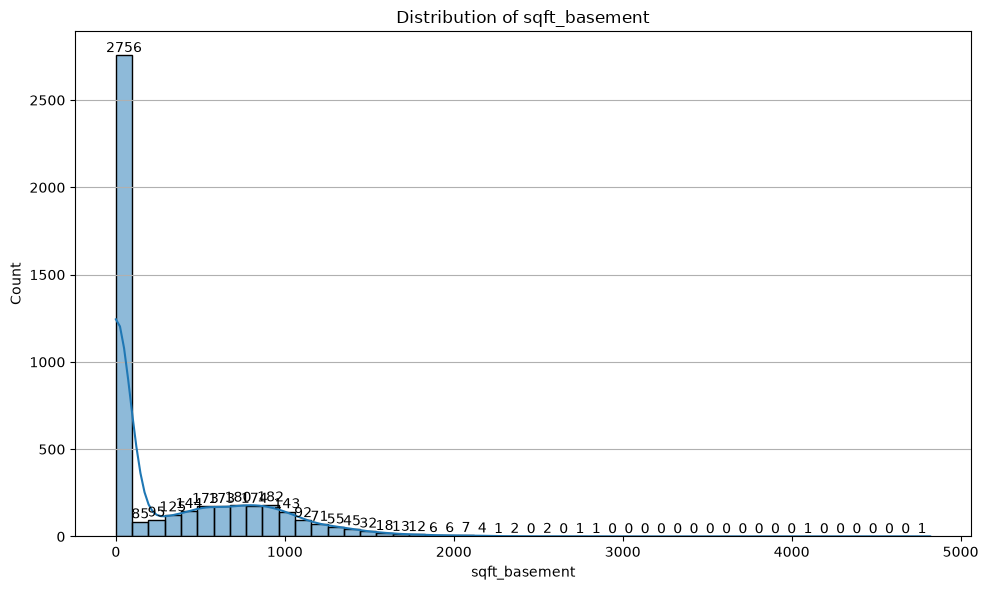

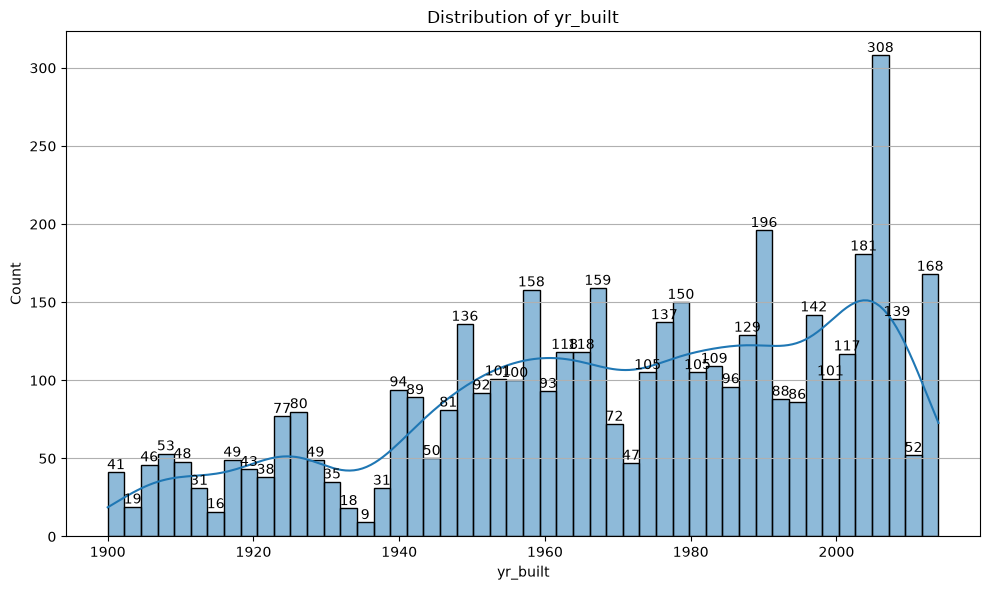

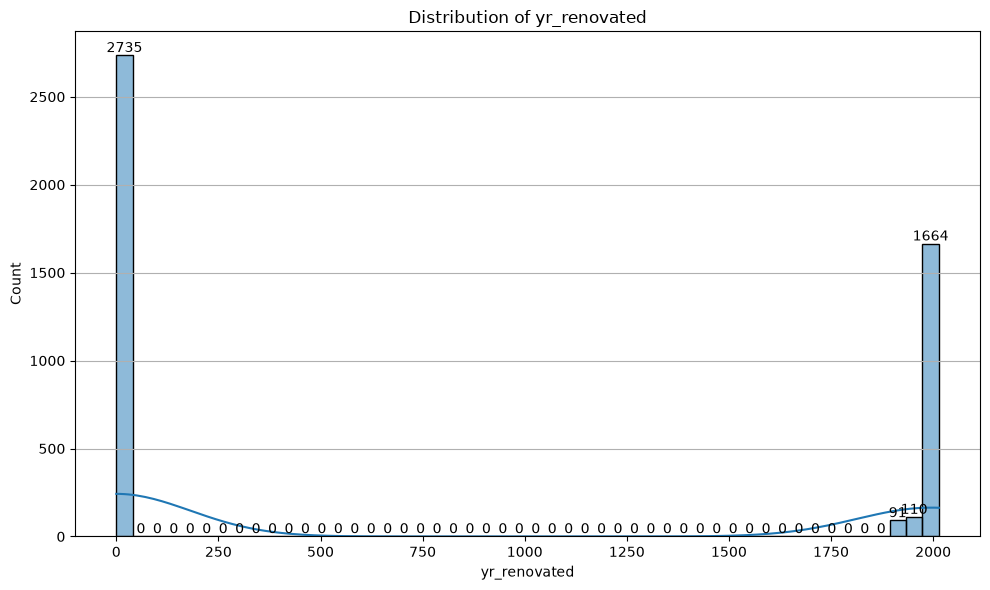

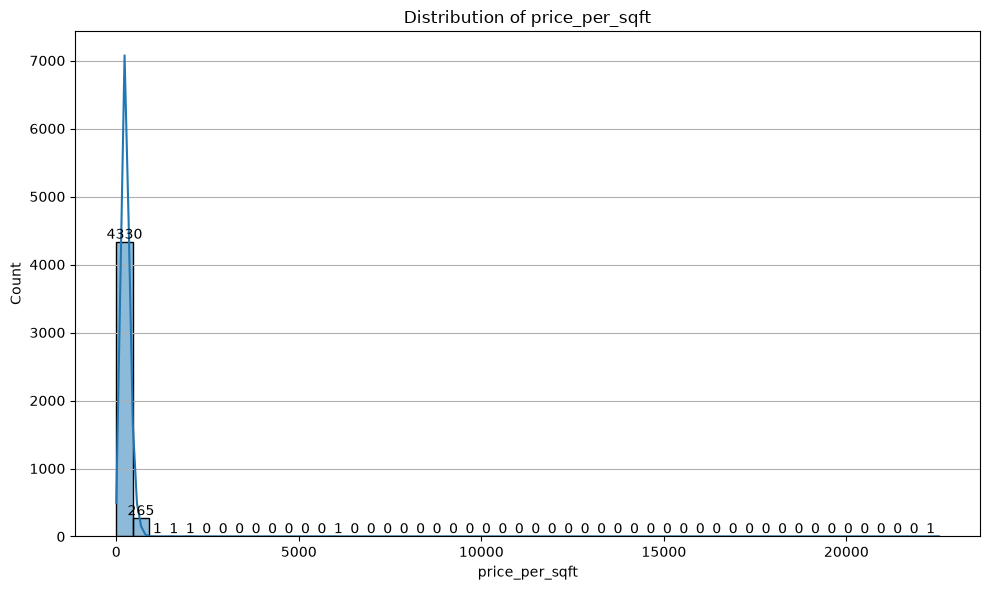

In [12]:

for col_name in numeric_cols:
    plt.figure(figsize=(10, 6))
    ax = sns.histplot(df[col_name], kde=True, bins=50,palette='colorblind')
    for container in ax.containers:
        ax.bar_label(container)
    plt.title(f'Distribution of {col_name}')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

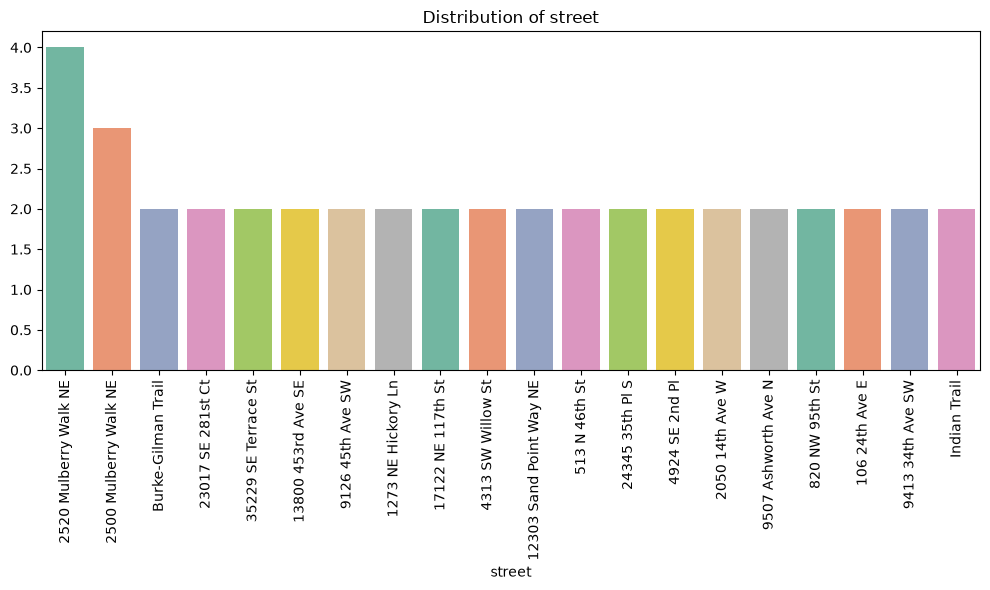

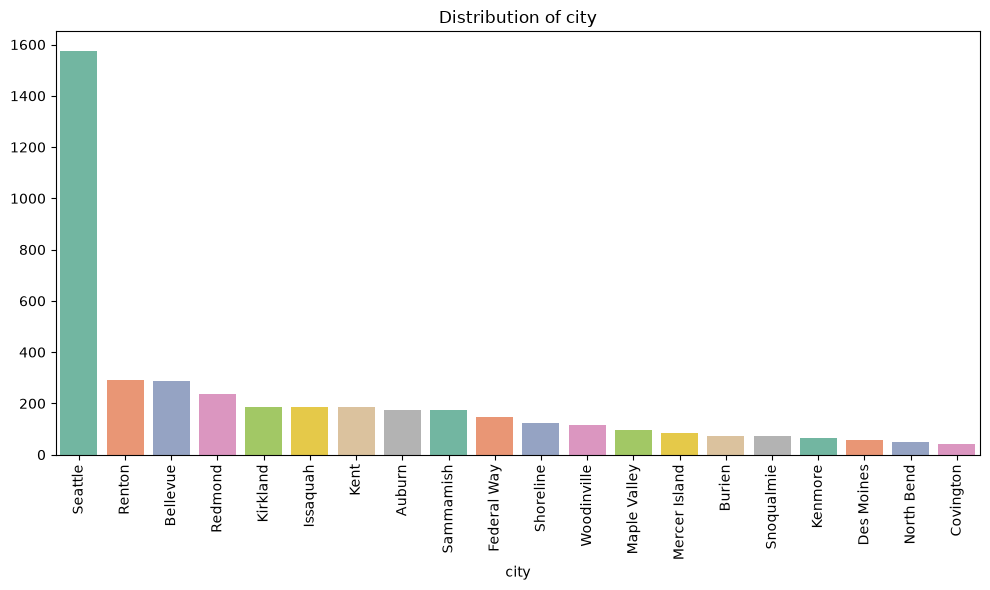

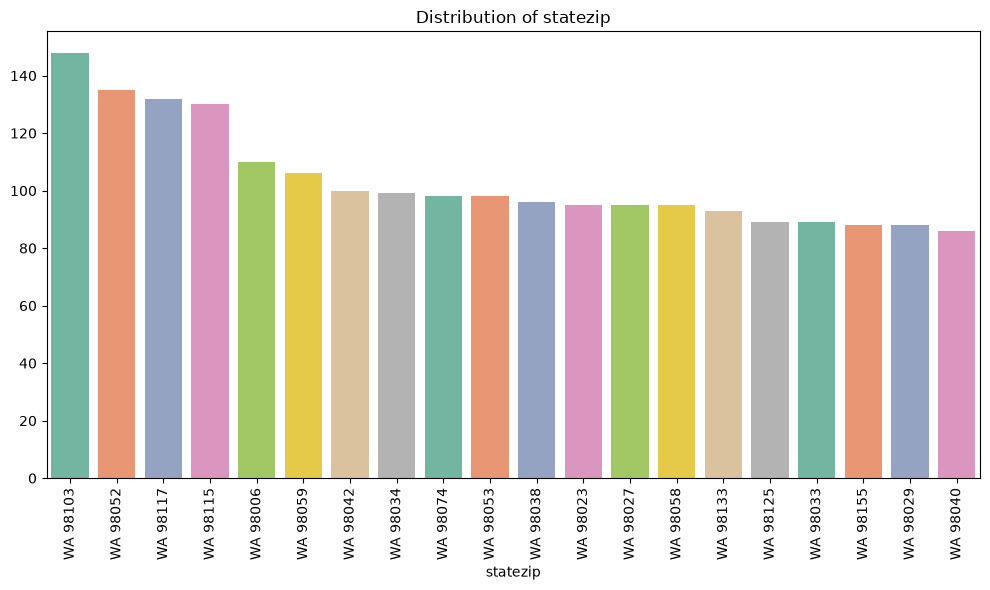

In [13]:
for col_name in categorical_cols:
    plt.figure(figsize=(10, 6))
    top_categories = df[col_name].value_counts().head(20)
    sns.barplot(x=top_categories.index, y=top_categories.values,palette='Set2')
    plt.title(f'Distribution of {col_name}')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

Analyzing the proportion of `view`.

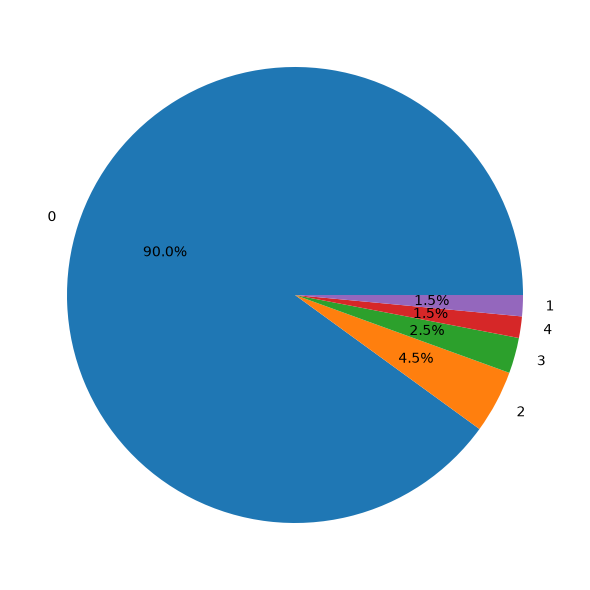

In [14]:
plt.figure(figsize=(10, 6))
count = df['view'].value_counts()
plt.pie(count, autopct='%1.1f%%', labels=count.index)
plt.tight_layout()
plt.show()

From the pie chart, a `view` value of `0` accounts for the large majority of the data — most homes have no recorded view.

### Bivariate Analysis

**1. Numeric vs. Numeric**

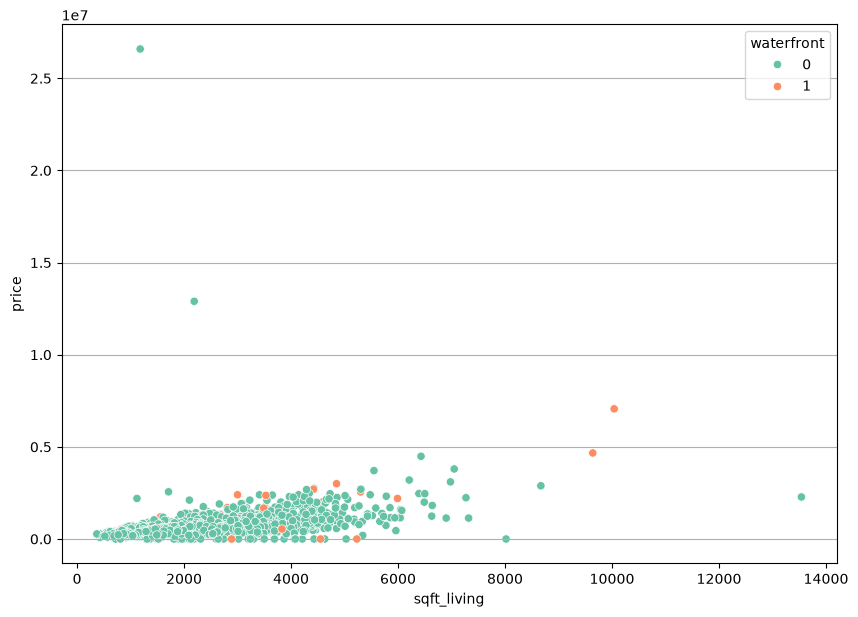

In [15]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, y='price', x='sqft_living',hue='waterfront',palette='Set2')
plt.grid(axis='y')
plt.show()


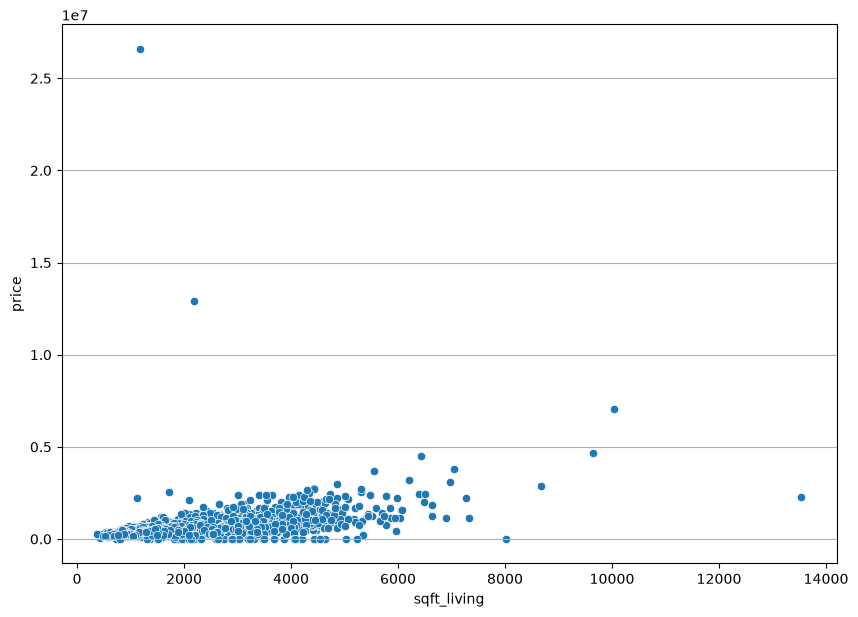

In [16]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, y='price', x='sqft_living')
plt.grid(axis='y')
plt.show()

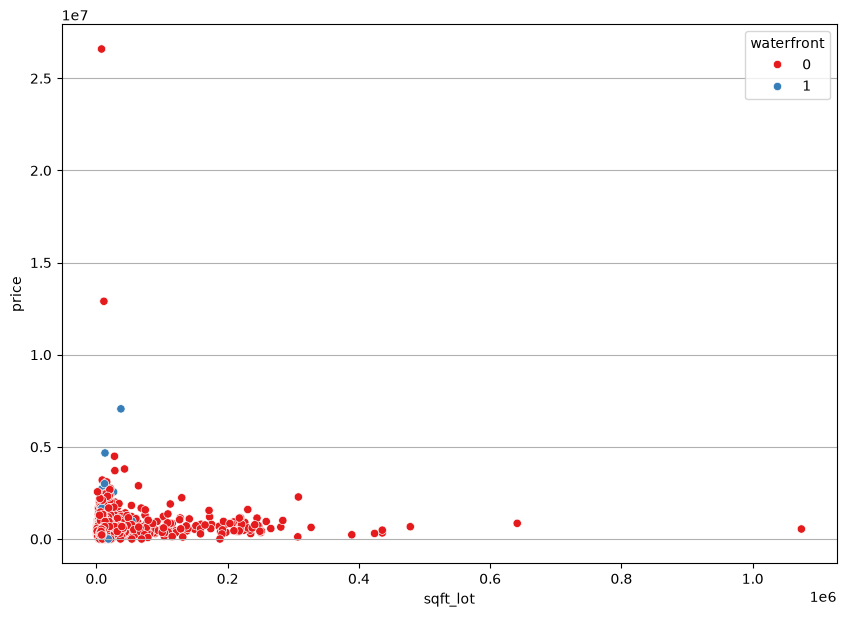

In [17]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, y='price', x='sqft_lot',hue='waterfront',palette='Set1')
plt.grid(axis='y')
plt.show()

**2. Numeric vs. Categorical**

Which city has the highest price?

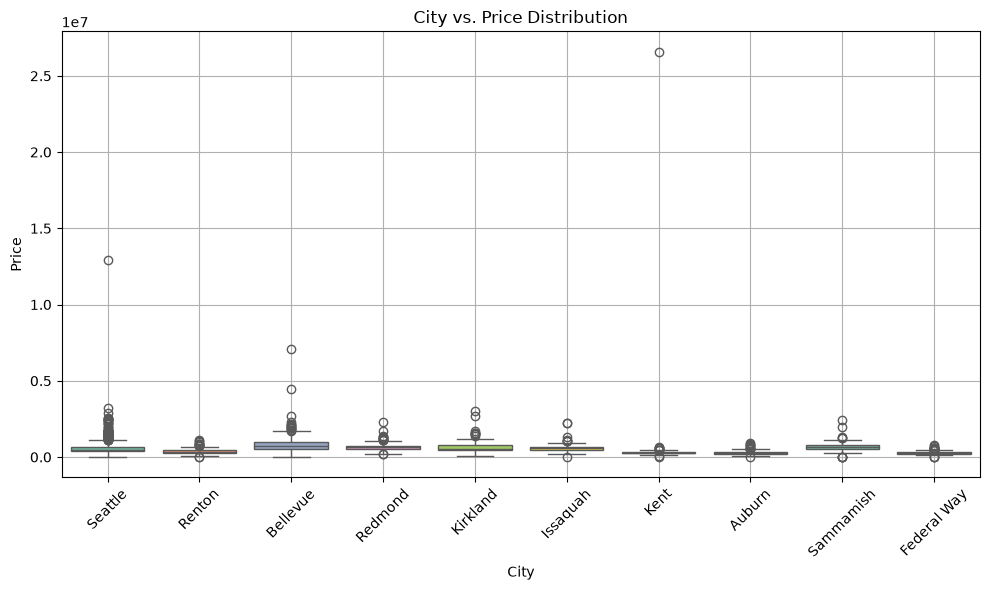

In [18]:
top_cities = df['city'].value_counts().head(10).index
df_top_cities = df[df['city'].isin(top_cities)]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_top_cities, y='price', x='city', order=top_cities, palette='Set2')
plt.title('City vs. Price Distribution')
plt.xlabel('City')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

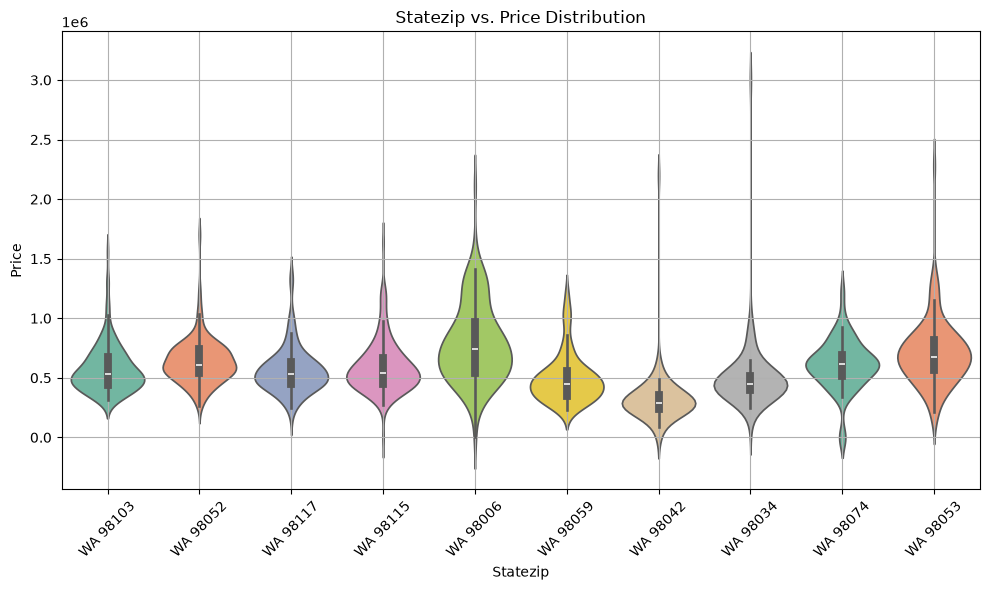

In [19]:
top_zipcode = df['statezip'].value_counts().head(10).index
df_top_zipcode = df[df['statezip'].isin(top_zipcode)]

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_top_zipcode, y='price', x='statezip', order=top_zipcode, palette='Set2')
plt.title('Statezip vs. Price Distribution')
plt.xlabel('Statezip')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

In [20]:
mean_price_df = (
    df.groupby('city')['price']
      .agg(['count', 'mean', 'median', 'min', 'max'])
      .sort_values(by='mean', ascending=False)
)
print("Top 10 Cities by Mean Price:")
print(mean_price_df.head(10))

Top 10 Cities by Mean Price:
                    count          mean     median       min        max
city                                                                   
Medina                 11  2.046559e+06  2100000.0  188000.0  3710000.0
Clyde Hill             11  1.321945e+06  1300000.0       0.0  3800000.0
Yarrow Point            4  1.194838e+06  1397000.0   84350.0  1901000.0
Mercer Island          86  1.123818e+06   948750.0       0.0  4668000.0
Bellevue              286  8.471807e+05   721500.0       0.0  7062500.0
Beaux Arts Village      1  7.450000e+05   745000.0  745000.0   745000.0
Fall City              11  6.926818e+05   563500.0  275000.0  1600000.0
Sammamish             175  6.869176e+05   665000.0       0.0  2400000.0
Redmond               235  6.676495e+05   638000.0  170000.0  2280000.0
Newcastle              33  6.660467e+05   602500.0  339900.0  1200000.0


### Multivariate Analysis

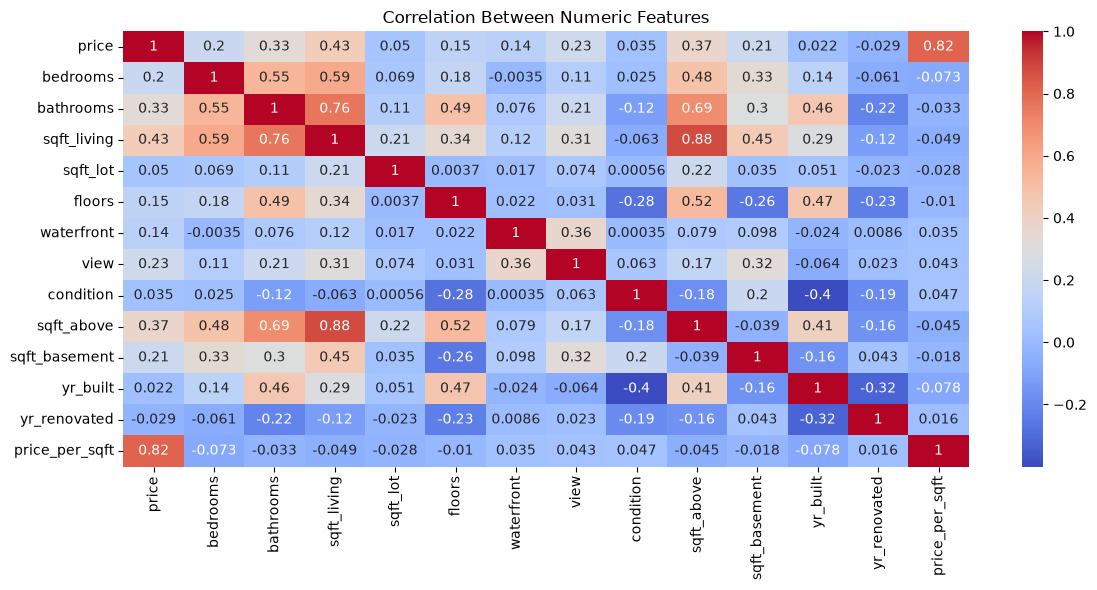

In [21]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Between Numeric Features')
plt.tight_layout()
plt.show()

## Data Cleaning

Check how many zero entries exist in key columns.

In [22]:
price_zeros = (df['price'] == 0).sum()
bedrooms_zeros = (df['bedrooms'] == 0).sum()
bathrooms_zeros = (df['bathrooms'] == 0).sum()

print(f'Zero entries in price: {price_zeros}')
print(f'Zero entries in bedrooms: {bedrooms_zeros}')
print(f'Zero entries in bathrooms: {bathrooms_zeros}')

Zero entries in price: 49
Zero entries in bedrooms: 2
Zero entries in bathrooms: 2


In [23]:
df = df[df['price'] > 0].reset_index(drop=True)
print(f"Zero entries in price after cleaning: {(df['price'] == 0).sum()}")

Zero entries in price after cleaning: 0


Removed rows where `price == 0` because price is the target variable — zero values are invalid/missing data that would distort training and evaluation metrics.

### Handling Zero Entries in Bedrooms and Bathrooms

- **Dropping criteria:** rows with `bedrooms == 0` or `bathrooms == 0` **and** negligible living area
  (`sqft_living < 500`) are removed outright — these look like non-residential or incomplete records.
- **Imputation criteria:** for the remaining valid properties, zero `bedrooms`/`bathrooms` values are
  replaced with the median. To avoid leaking test-set information into that median, the imputation is
  computed **after** the train/test split, using training data only (see the "Machine Learning" section
  below). This cell only performs the row-drop step.


In [24]:
df[(df['bedrooms'] == 0) | (df['bathrooms'] == 0)]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
2365,2014-06-12,1095000.0,0.0,0.0,3064,4764,3.5,0,2,3,3064,0,1990,2009,814 E Howe St,Seattle,WA 98102,357.38
3209,2014-06-24,1295648.0,0.0,0.0,4810,28008,2.0,0,0,3,4810,0,1990,2009,20418 NE 64th Pl,Redmond,WA 98053,269.37


In [25]:
drop_mask = ((df['bedrooms'] == 0) | (df['bathrooms'] == 0)) & (df['sqft_living'] < 500)
print(f"Dropping {drop_mask.sum()} rows with zero bed/bath and negligible living area")
df = df[~drop_mask].reset_index(drop=True)

remaining_zero_beds = (df['bedrooms'] == 0).sum()
remaining_zero_baths = (df['bathrooms'] == 0).sum()
print(f'Remaining zero bedrooms: {remaining_zero_beds} (to be median-imputed post-split)')
print(f'Remaining zero bathrooms: {remaining_zero_baths} (to be median-imputed post-split)')

Dropping 0 rows with zero bed/bath and negligible living area
Remaining zero bedrooms: 2 (to be median-imputed post-split)
Remaining zero bathrooms: 2 (to be median-imputed post-split)


Dataset is now free of invalid price rows and non-residential zero-bed/bath rows. Remaining zero bed/bath values will be median-imputed later using training-set statistics only.

## Feature Engineering

In [26]:
# House age at time of sale
df['Sale_year'] = df['date'].dt.year
df['House_age'] = df['Sale_year'] - df['yr_built']

# Drop the original date column (info is now captured by Sale_year / House_age)
df = df.drop(columns=['date'])

# Was the house ever renovated?
df['is_renovated'] = (df['yr_renovated'] > 0).astype(int)

# Does the house have a recorded view?
df['has_view'] = (df['view'] > 0).astype(int)

# Is the house in good condition (rating >= 4)?
df['Is_Good_Condition'] = (df['condition'] >= 4).astype(int)

# Total living area (living + basement)
df['total_sqft'] = df['sqft_living'] + df['sqft_basement']

In [27]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,...,street,city,statezip,price_per_sqft,Sale_year,House_age,is_renovated,has_view,Is_Good_Condition,total_sqft
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,...,18810 Densmore Ave N,Shoreline,WA 98133,233.58,2014,59,1,0,0,1340
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,...,709 W Blaine St,Seattle,WA 98119,653.15,2014,93,0,1,1,3930
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,...,26206-26214 143rd Ave SE,Kent,WA 98042,177.20,2014,48,0,0,1,1930
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,...,857 170th Pl NE,Bellevue,WA 98008,210.00,2014,51,0,0,1,3000
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,...,9105 170th Ave NE,Redmond,WA 98052,283.51,2014,38,1,0,1,2740


### Removing redundant / collinear columns

Several engineered features duplicate information already present in the raw columns. Left in together
they don't help tree-based models much, but they destabilize linear-model coefficients and clutter the
correlation-based feature selection below, so we keep exactly one representation of each concept:

| Concept | Keep | Drop |
|---|---|---|
| View | `has_view` (binary, matches the 90%+ "no view" skew seen in EDA) | `view` |
| Condition | `Is_Good_Condition` (binary) | `condition` |
| Size | `sqft_living`, `sqft_basement` (already granular) | `total_sqft` (their exact sum) |
| Age | `House_age` | `yr_built`, `Sale_year` (`House_age` is a linear combination of both) |


In [28]:
df = df.drop(columns=['view', 'condition', 'total_sqft', 'yr_built', 'Sale_year'])
df.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'sqft_above', 'sqft_basement', 'yr_renovated', 'street',
       'city', 'statezip', 'price_per_sqft', 'House_age', 'is_renovated',
       'has_view', 'Is_Good_Condition'],
      dtype='str')

### Encoding categorical features

In [29]:
df_encoded = df.copy()

# Extract numeric zipcode out of 'WA 98133' style strings
df_encoded['zipcode'] = df['statezip'].str.extract(r'(\d+)').astype(int)
df_encoded = df_encoded.drop(columns=['statezip'])

# One-hot encode city
df_encoded = pd.get_dummies(df_encoded, columns=['city'], drop_first=True, dtype=int)

**Feature Selection — dropping `street`:**
- Too many unique values: one-hot encoding thousands of unique addresses creates an unmanageable number of columns.
- Prevents overfitting: stops the model from memorizing individual homes instead of learning general patterns.
- Redundant location info: geography is already captured by `city` and `zipcode`.


In [30]:
df_encoded = df_encoded.drop(columns=['street'])

In [31]:
df_encoded.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,sqft_above,sqft_basement,yr_renovated,...,city_SeaTac,city_Seattle,city_Shoreline,city_Skykomish,city_Snoqualmie,city_Snoqualmie Pass,city_Tukwila,city_Vashon,city_Woodinville,city_Yarrow Point
0,313000.0,3.0,1.50,1340,7912,1.5,0,1340,0,2005,...,0,0,1,0,0,0,0,0,0,0
1,2384000.0,5.0,2.50,3650,9050,2.0,0,3370,280,0,...,0,1,0,0,0,0,0,0,0,0
2,342000.0,3.0,2.00,1930,11947,1.0,0,1930,0,0,...,0,0,0,0,0,0,0,0,0,0
3,420000.0,3.0,2.25,2000,8030,1.0,0,1000,1000,0,...,0,0,0,0,0,0,0,0,0,0
4,550000.0,4.0,2.50,1940,10500,1.0,0,1140,800,1992,...,0,0,0,0,0,0,0,0,0,0


In [32]:
corr_with_target = df_encoded.corr(numeric_only=True)['price'].sort_values(ascending=False)
print("Correlation with target variable (price):")
print(corr_with_target)

Correlation with target variable (price):
price                       1.000000
price_per_sqft              0.818099
sqft_living                 0.445494
sqft_above                  0.380661
bathrooms                   0.341126
has_view                    0.228720
sqft_basement               0.217782
bedrooms                    0.210228
floors                      0.152758
waterfront                  0.150083
city_Mercer Island          0.149117
city_Bellevue               0.138463
city_Medina                 0.129952
city_Clyde Hill             0.083508
sqft_lot                    0.051347
city_Sammamish              0.050838
city_Redmond                0.045415
city_Kirkland               0.034390
city_Seattle                0.033815
city_Yarrow Point           0.033503
city_Newcastle              0.016391
city_Woodinville            0.016205
city_Issaquah               0.015179
Is_Good_Condition           0.014115
city_Fall City              0.011765
city_Beaux Arts Village     0.004

## Machine Learning

In [33]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

`price_per_sqft` is dropped from `X` along with `price` because it's derived directly from `price` and `sqft_living` — keeping it would cause data leakage.

In [34]:
X = df_encoded.drop(columns=['price', 'price_per_sqft'])
y = df_encoded['price']

feature_columns = X.columns.tolist()  # saved later for consistent inference

In [35]:
df.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'sqft_above', 'sqft_basement', 'yr_renovated', 'street',
       'city', 'statezip', 'price_per_sqft', 'House_age', 'is_renovated',
       'has_view', 'Is_Good_Condition'],
      dtype='str')

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Post-split cleanup: median-impute remaining zero bed/bath values (training set only)

In [37]:
# CHANGED: retain training-only medians for inference in the Streamlit app.
zero_imputation_medians = {}
for col in ['bedrooms', 'bathrooms']:
    train_median = X_train.loc[X_train[col] != 0, col].median()
    zero_imputation_medians[col] = train_median
    X_train[col] = X_train[col].replace(0, train_median)
    X_test[col] = X_test[col].replace(0, train_median)

print('Training-only replacement medians:', zero_imputation_medians)


Training-only replacement medians: {'bedrooms': np.float64(3.0), 'bathrooms': np.float64(2.25)}


### Feature Scaling

In [38]:
std_cols = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
            'sqft_above', 'sqft_basement', 'yr_renovated', 'House_age', 'zipcode']

scaler = StandardScaler()
X_train[std_cols] = scaler.fit_transform(X_train[std_cols])   # fit on TRAIN only
X_test[std_cols] = scaler.transform(X_test[std_cols])         # transform test with the same scaler

### Log-transform the target

Computed once and reused by every model below (previously recomputed identically in every model cell).

In [39]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

### Evaluation helper


In [40]:
results = []

def evaluate_model(name, fitted_model, X_train, y_train_log, X_test, y_test_log):
    train_pred = fitted_model.predict(X_train)
    test_pred = fitted_model.predict(X_test)

    metrics = {
        'Model Name': name,
        'Train R2': round(r2_score(y_train_log, train_pred), 2),
        'Test R2': round(r2_score(y_test_log, test_pred), 2),
        'Test MAE (log)': round(mean_absolute_error(y_test_log, test_pred), 5),
        'Test RMSE (log)': round(np.sqrt(mean_squared_error(y_test_log, test_pred)), 5),
    }
    results.append(metrics)

    print(f"--- {name} ---")
    print(f"Train R2: {metrics['Train R2']}")
    print(f"Test R2:  {metrics['Test R2']}")
    print(f"Test MAE (log): {metrics['Test MAE (log)']}")
    print(f"Test RMSE (log): {metrics['Test RMSE (log)']}")
    return metrics

### 1. Linear Regression

In [41]:
model = LinearRegression()
model.fit(X_train, y_train_log)
evaluate_model('Linear Regression', model, X_train, y_train_log, X_test, y_test_log)

--- Linear Regression ---
Train R2: 0.72
Test R2:  0.68
Test MAE (log): 0.20009
Test RMSE (log): 0.29683


{'Model Name': 'Linear Regression',
 'Train R2': 0.72,
 'Test R2': 0.68,
 'Test MAE (log)': 0.20009,
 'Test RMSE (log)': np.float64(0.29683)}

### 2. Decision Tree

In [42]:
trmodel = DecisionTreeRegressor(random_state=42)
trmodel.fit(X_train, y_train_log)
evaluate_model('Decision Tree', trmodel, X_train, y_train_log, X_test, y_test_log)

--- Decision Tree ---
Train R2: 1.0
Test R2:  0.31
Test MAE (log): 0.27293
Test RMSE (log): 0.43538


{'Model Name': 'Decision Tree',
 'Train R2': 1.0,
 'Test R2': 0.31,
 'Test MAE (log)': 0.27293,
 'Test RMSE (log)': np.float64(0.43538)}

### 3. Random Forest

In [43]:
rfmodel = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rfmodel.fit(X_train, y_train_log)
evaluate_model('Random Forest', rfmodel, X_train, y_train_log, X_test, y_test_log)

--- Random Forest ---
Train R2: 0.96
Test R2:  0.73
Test MAE (log): 0.18568
Test RMSE (log): 0.272


{'Model Name': 'Random Forest',
 'Train R2': 0.96,
 'Test R2': 0.73,
 'Test MAE (log)': 0.18568,
 'Test RMSE (log)': np.float64(0.272)}

### 4. Gradient Boosting (hyperparameter-tuned)

In [44]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.8, 1.0],
    'min_samples_split': [2, 5, 10]
}

random_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
random_search.fit(X_train, y_train_log)

print("Best Parameters:", random_search.best_params_)

# Use the tuned estimator directly instead of re-typing the params by hand
# (this was the source of the GradientBoostingRegr typo in the original notebook).
gbmodel = random_search.best_estimator_
evaluate_model('Gradient Boosting', gbmodel, X_train, y_train_log, X_test, y_test_log)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 3, 'learning_rate': 0.1}
--- Gradient Boosting ---
Train R2: 0.89
Test R2:  0.76
Test MAE (log): 0.17105
Test RMSE (log): 0.25606


{'Model Name': 'Gradient Boosting',
 'Train R2': 0.89,
 'Test R2': 0.76,
 'Test MAE (log)': 0.17105,
 'Test RMSE (log)': np.float64(0.25606)}

### 5. AdaBoost

In [45]:
adamodel = AdaBoostRegressor(random_state=42)
adamodel.fit(X_train, y_train_log)
evaluate_model('AdaBoost', adamodel, X_train, y_train_log, X_test, y_test_log)

--- AdaBoost ---
Train R2: 0.48
Test R2:  0.44
Test MAE (log): 0.31181
Test RMSE (log): 0.39493


{'Model Name': 'AdaBoost',
 'Train R2': 0.48,
 'Test R2': 0.44,
 'Test MAE (log)': 0.31181,
 'Test RMSE (log)': np.float64(0.39493)}

### 6. KNN

In [46]:
knmodel = KNeighborsRegressor()
knmodel.fit(X_train, y_train_log)
evaluate_model('KNN', knmodel, X_train, y_train_log, X_test, y_test_log)

--- KNN ---
Train R2: 0.75
Test R2:  0.64
Test MAE (log): 0.22287
Test RMSE (log): 0.31392


{'Model Name': 'KNN',
 'Train R2': 0.75,
 'Test R2': 0.64,
 'Test MAE (log)': 0.22287,
 'Test RMSE (log)': np.float64(0.31392)}

### 7. SVM

In [47]:
svmmodel = SVR()
svmmodel.fit(X_train, y_train_log)
evaluate_model('SVM', svmmodel, X_train, y_train_log, X_test, y_test_log)

--- SVM ---
Train R2: 0.8
Test R2:  0.71
Test MAE (log): 0.18988
Test RMSE (log): 0.2848


{'Model Name': 'SVM',
 'Train R2': 0.8,
 'Test R2': 0.71,
 'Test MAE (log)': 0.18988,
 'Test RMSE (log)': np.float64(0.2848)}

### Model Comparison

In [48]:
comparison_df = pd.DataFrame(results).sort_values(by='Test R2', ascending=False).reset_index(drop=True)
comparison_df

,Model Name,Train R2,Test R2,Test MAE (log),Test RMSE (log)
0,Gradient Boosting,0.89,0.76,0.17105,0.25606
1,Random Forest,0.96,0.73,0.18568,0.27200
2,SVM,0.80,0.71,0.18988,0.28480
3,Linear Regression,0.72,0.68,0.20009,0.29683
4,KNN,0.75,0.64,0.22287,0.31392
5,AdaBoost,0.48,0.44,0.31181,0.39493
6,Decision Tree,1.00,0.31,0.27293,0.43538


### Feature Importance


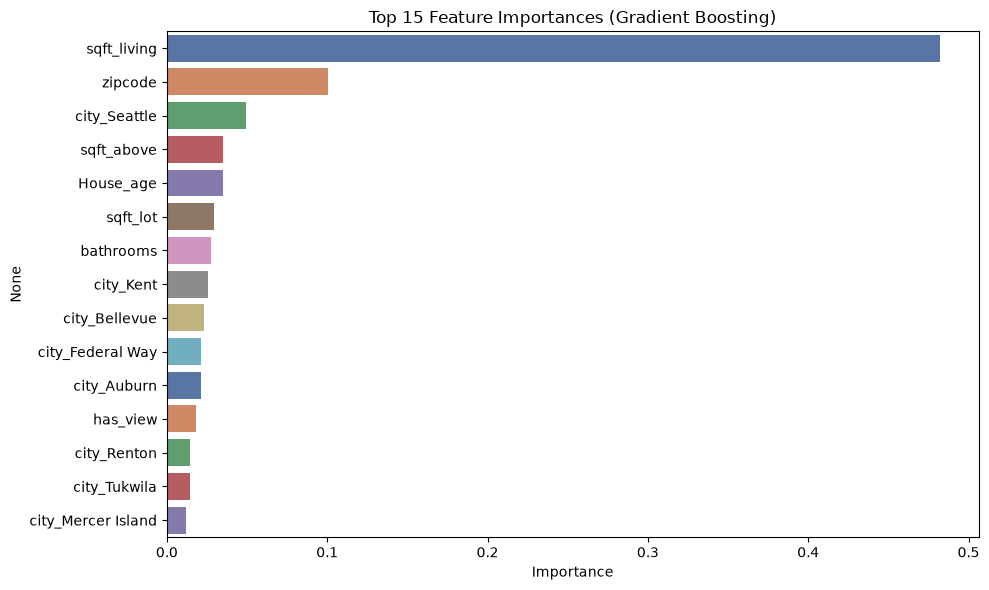

In [49]:
best_model_name = comparison_df.iloc[0]['Model Name']
tree_models = {
    'Random Forest': rfmodel,
    'Gradient Boosting': gbmodel,
    'Decision Tree': trmodel,
    'AdaBoost': adamodel,
}

if best_model_name in tree_models:
    importances = pd.Series(
        tree_models[best_model_name].feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances.values, y=importances.index, palette='deep')
    plt.title(f'Top 15 Feature Importances ({best_model_name})')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} has no .feature_importances_ attribute (not a tree-based model); "
          "use permutation_importance instead if this model wins.")

 Save Gradient Boosting model



 Save all files required by the Streamlit app




In [50]:
#: Save all fitted objects and inference metadata.
import joblib

joblib.dump(gbmodel, 'gradient_boosting_house_model.pkl')
joblib.dump(scaler, 'scaler.pkl')


print('Saved: gradient_boosting_house_model.pkl')
print('Saved: scaler.pkl')


Saved: gradient_boosting_house_model.pkl
Saved: scaler.pkl


In [51]:
X.columns

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'sqft_above', 'sqft_basement', 'yr_renovated',
       'House_age', 'is_renovated', 'has_view', 'Is_Good_Condition', 'zipcode',
       'city_Auburn', 'city_Beaux Arts Village', 'city_Bellevue',
       'city_Black Diamond', 'city_Bothell', 'city_Burien', 'city_Carnation',
       'city_Clyde Hill', 'city_Covington', 'city_Des Moines', 'city_Duvall',
       'city_Enumclaw', 'city_Fall City', 'city_Federal Way',
       'city_Inglewood-Finn Hill', 'city_Issaquah', 'city_Kenmore',
       'city_Kent', 'city_Kirkland', 'city_Lake Forest Park',
       'city_Maple Valley', 'city_Medina', 'city_Mercer Island', 'city_Milton',
       'city_Newcastle', 'city_Normandy Park', 'city_North Bend',
       'city_Pacific', 'city_Preston', 'city_Ravensdale', 'city_Redmond',
       'city_Renton', 'city_Sammamish', 'city_SeaTac', 'city_Seattle',
       'city_Shoreline', 'city_Skykomish', 'city_Snoqualmie',
       'city_Sno

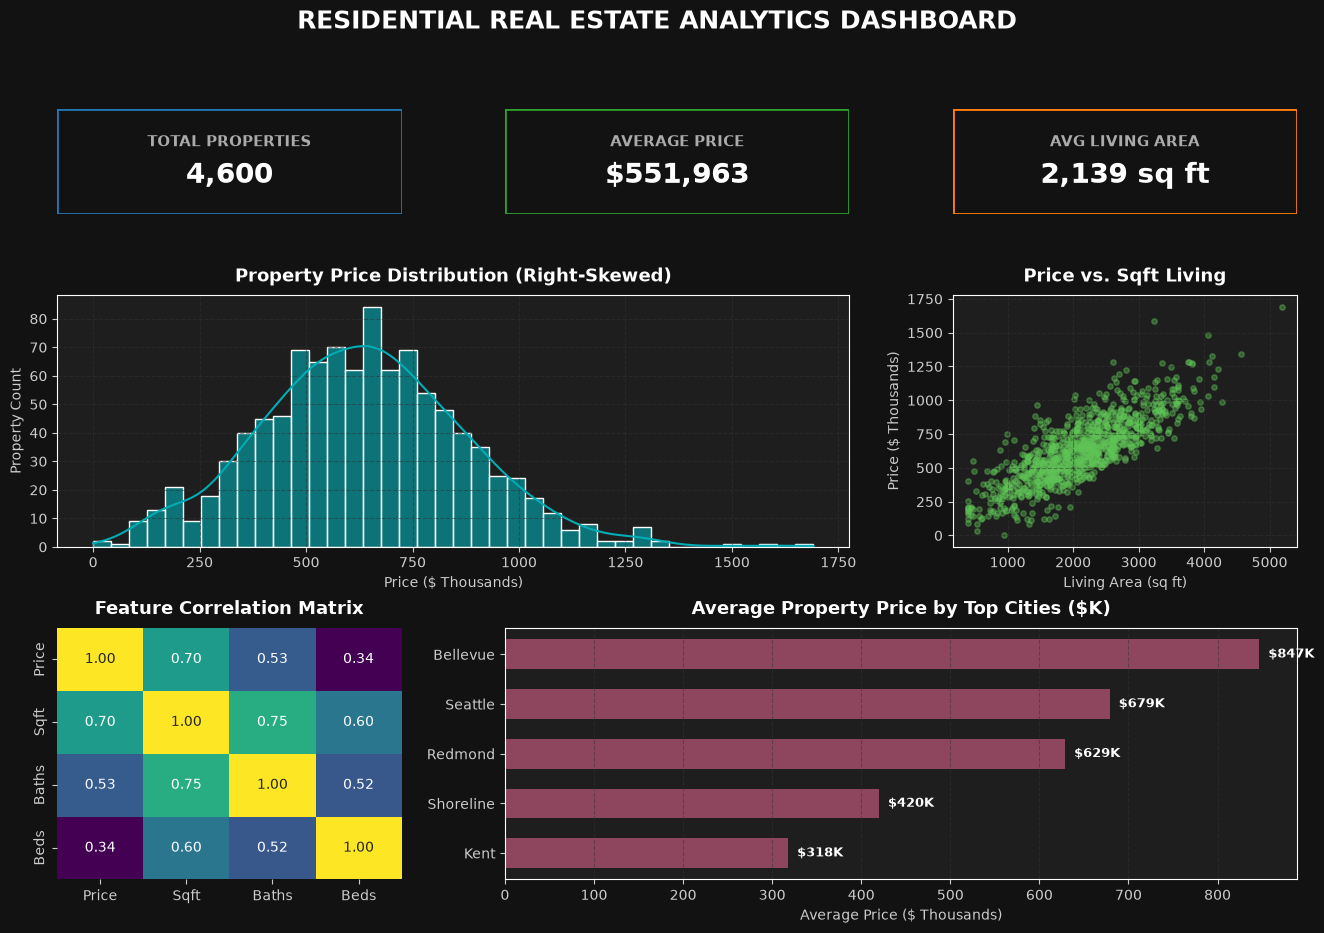

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set dark theme for a modern aesthetic
plt.style.use('dark_background')
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#121212')

# Create a grid layout: 2 rows for KPIs/Visuals
gs = fig.add_gridspec(3, 3, height_ratios=[0.5, 1.2, 1.2], hspace=0.4, wspace=0.3)

# ---------------------------------------------------------
# 1. KPI Metric Cards
# ---------------------------------------------------------
kpis = [
    ("TOTAL PROPERTIES", "4,600", "#1f77b4"),
    ("AVERAGE PRICE", "$551,963", "#2ca02c"),
    ("AVG LIVING AREA", "2,139 sq ft", "#ff7f0e")
]

for idx, (title, val, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, idx])
    ax.set_facecolor('#1e1e1e')
    ax.axis('off')
    # Add border effect
    rect = plt.Rectangle((0, 0), 1, 1, fill=False, edgecolor=color, lw=2, transform=ax.transAxes)
    ax.add_patch(rect)
    
    ax.text(0.5, 0.65, title, color='#aaaaaa', fontsize=11, ha='center', weight='bold')
    ax.text(0.5, 0.3, val, color='white', fontsize=20, ha='center', weight='bold')

# ---------------------------------------------------------
# 2. Simulated Data Generation (matching dataset distribution)
# ---------------------------------------------------------
np.random.seed(42)
n_samples = 1000
sqft = np.random.normal(2100, 800, n_samples).clip(400, 10000)
price = sqft * 250 + np.random.normal(0, 100000, n_samples) + np.random.exponential(100000, n_samples)
price = price.clip(0, 3000000)

df = pd.DataFrame({'sqft_living': sqft, 'price': price})

# ---------------------------------------------------------
# 3. Chart 1: Price Distribution Plot
# ---------------------------------------------------------
ax1 = fig.add_subplot(gs[1, 0:2])
ax1.set_facecolor('#1e1e1e')
sns.histplot(df['price'] / 1e3, kde=True, ax=ax1, color='#00adb5', bins=40, alpha=0.6)
ax1.set_title('Property Price Distribution (Right-Skewed)', color='white', fontsize=13, pad=10, weight='bold')
ax1.set_xlabel('Price ($ Thousands)', color='#cccccc')
ax1.set_ylabel('Property Count', color='#cccccc')
ax1.tick_params(colors='#cccccc')
ax1.grid(color='#333333', linestyle='--', alpha=0.5)

# ---------------------------------------------------------
# 4. Chart 2: Sqft vs. Price Scatter Plot
# ---------------------------------------------------------
ax2 = fig.add_subplot(gs[1, 2])
ax2.set_facecolor('#1e1e1e')
ax2.scatter(df['sqft_living'], df['price'] / 1e3, alpha=0.4, color="#60C457", s=15)
ax2.set_title('Price vs. Sqft Living', color='white', fontsize=13, pad=10, weight='bold')
ax2.set_xlabel('Living Area (sq ft)', color='#cccccc')
ax2.set_ylabel('Price ($ Thousands)', color='#cccccc')
ax2.tick_params(colors='#cccccc')
ax2.grid(color='#333333', linestyle='--', alpha=0.5)

# ---------------------------------------------------------
# 5. Chart 3: Correlation Heatmap
# ---------------------------------------------------------
ax3 = fig.add_subplot(gs[2, 0])
ax3.set_facecolor('#1e1e1e')
corr_data = pd.DataFrame({
    'Price': [1.0, 0.70, 0.53, 0.34],
    'Sqft': [0.70, 1.0, 0.75, 0.60],
    'Baths': [0.53, 0.75, 1.0, 0.52],
    'Beds': [0.34, 0.60, 0.52, 1.0]
}, index=['Price', 'Sqft', 'Baths', 'Beds'])

sns.heatmap(corr_data, annot=True, cmap='viridis', ax=ax3, cbar=False, fmt='.2f', annot_kws={"size": 10})
ax3.set_title('Feature Correlation Matrix', color='white', fontsize=13, pad=10, weight='bold')
ax3.tick_params(colors='#cccccc')

# ---------------------------------------------------------
# 6. Chart 4: Top Cities by Average Price
# ---------------------------------------------------------
ax4 = fig.add_subplot(gs[2, 1:3])
ax4.set_facecolor('#1e1e1e')
cities = ['Bellevue', 'Seattle', 'Redmond', 'Shoreline', 'Kent']
avg_prices = [847, 679, 629, 420, 318]

bars = ax4.barh(cities, avg_prices, color="#ab516f", alpha=0.8, edgecolor='none', height=0.6)
ax4.set_title('Average Property Price by Top Cities ($K)', color='white', fontsize=13, pad=10, weight='bold')
ax4.set_xlabel('Average Price ($ Thousands)', color='#cccccc')
ax4.tick_params(colors='#cccccc')
ax4.grid(color='#333333', linestyle='--', alpha=0.5, axis='x')
ax4.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax4.text(width + 10, bar.get_y() + bar.get_height()/2, f'${width}K', 
             va='center', color='white', fontweight='bold', fontsize=9)

# Dashboard Super Title
fig.suptitle('RESIDENTIAL REAL ESTATE ANALYTICS DASHBOARD', color='white', fontsize=18, weight='bold', y=0.98)

# Save image locally
plt.savefig('house_price_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()